BOOK RECOMMENDATION

The main objective is to create a recommendation system to recommend relevant books to users based on popularity and user interests.

The Book-Crossing dataset comprises 3 files
1.Users :
Contains the users. Note that user IDs (User-ID) have been anonymized and map to integers. Demographic data is provided (Location, Age) if available. Otherwise, these fields contain NULL values.
2.Books :
Books are identified by their respective ISBN. Invalid ISBNs have already been removed from the dataset. Moreover, some content-based information is given (Book-Title, Book-Author, Year-Of-Publication, Publisher), obtained from Amazon Web Services. Note that in the case of several authors, only the first is provided. URLs linking to cover images are also given, appearing in three different flavors (Image-URL-S, Image-URL-M, Image-URL-L), i.e., small, medium, large. These URLs point to the Amazon website.
3.Ratings :
Contains the book rating information. Ratings (Book-Rating) are either explicit, expressed on a scale from 1-10 (higher values denoting higher appreciation), or implicit, expressed by 0.

In [1]:
import warnings

In [2]:
warnings.filterwarnings('ignore')

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

LOADING DATASET

In [4]:
books = pd.read_csv("Books.csv", encoding="latin-1", error_bad_lines=False)
books.head(2)

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...


In [5]:
users = pd.read_csv("Users.csv",encoding="latin-1", error_bad_lines=False)
users.head(2)

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0


In [6]:
ratings = pd.read_csv("Ratings.csv", encoding="latin-1", error_bad_lines=False)
ratings.head(2)

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5


In [7]:
# dimension of dataset
print(f'''\t  Book_df shape is {books.shape}
          Ratings_df shape is {ratings.shape}
          Users_df shape is {users.shape}''')
     

	  Book_df shape is (271360, 8)
          Ratings_df shape is (1149780, 3)
          Users_df shape is (278858, 3)


DATA PREPROCESSING

In [8]:
books = books[['ISBN', 'Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher']]

We removed unnecessary columns and rename the feature names for easy understanding

In [9]:
books.rename(columns = {'Book-Title':'title', 'Book-Author':'author', 'Year-Of-Publication':'year', 'Publisher':'publisher'}, inplace=True)
users.rename(columns = {'User-ID':'user_id', 'Location':'location', 'Age':'age'}, inplace=True)
ratings.rename(columns = {'User-ID':'user_id', 'Book-Rating':'rating'}, inplace=True)

In [10]:
books.head(2)

,ISBN,title,author,year,publisher
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada


USERS DATASET

In [11]:
users.head(2)

,user_id,location,age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0


In [12]:
Missing_values=users.isnull().sum()
Percentage_missing_values=round(users.isnull().mean().mul(100),2)
Data_type=users.dtypes

In [13]:
mz_table=pd.concat([Missing_values,Percentage_missing_values,Data_type],axis=1)
mz_table=mz_table.rename(columns={users.index.name:'col_name',0:'Missing_values',1:'Percentage_missing_values',2:'Data_type'})
mz_table=mz_table.sort_values('Percentage_missing_values',ascending=False)
mz_table

,Missing_values,Percentage_missing_values,Data_type
age,110762,39.72,float64
user_id,0,0.00,int64
location,0,0.00,object


Age have around 39% missing values.

Distribution of age in users dataset

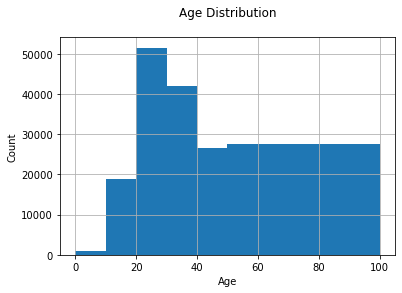

In [14]:
users.age.hist(bins=[0, 10, 20, 30, 40, 50, 100])
plt.title('Age Distribution\n')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

The most active users are among those in their 20–30s.

Distribution of Location in users dataset

In [15]:
users.location.unique()

array(['nyc, new york, usa', 'stockton, california, usa',
       'moscow, yukon territory, russia', ...,
       'sergnano, lombardia, italy', 'stranraer, n/a, united kingdom',
       'tacoma, washington, united kingdom'], dtype=object)

In [16]:
users.location.nunique()

57339

Extracting the countries from the location since there is more number of location

In [17]:
user_location_expanded = users.location.str.split(',', 2, expand=True)
user_location_expanded.columns = ['city', 'state', 'country']
users = users.join(user_location_expanded)

In [18]:
users.country.nunique()

1276

In [19]:
#drop location column
users.drop('location',axis=1,inplace=True)

In [20]:
users.isnull().sum()

user_id         0
age        110762
city            0
state           1
country         2
dtype: int64

In [21]:
users['country']=users['country'].astype('str')

In [22]:
users.country.unique()

array([' usa', ' russia', ' portugal', ..., ' la svizzera', ' hernando',
       ' united kingdom.'], dtype=object)

In [23]:
empty_string_country = users[users.country == ''].country.count()
nan_country = users.country.isnull().sum()
print(f'There are {empty_string_country} entries with empty strings, and {nan_country} NaN entries in the Country field')

There are 4561 entries with empty strings, and 0 NaN entries in the Country field


In [24]:
users.country.replace('', np.nan, inplace=True)
users.isna().sum()

user_id         0
age        110762
city            0
state           1
country      4561
dtype: int64

Text(0.5, 1.0, 'Count of users Country wise')

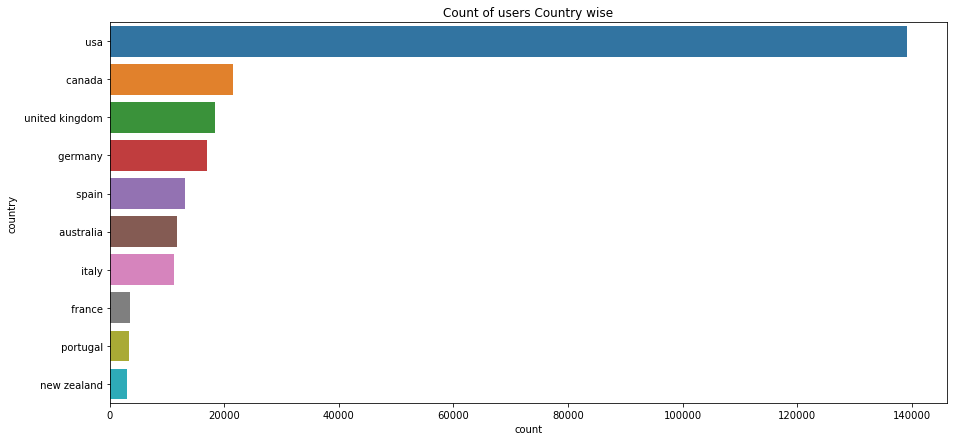

In [25]:
plt.figure(figsize=(15,7))
sns.countplot(y='country',data=users,order=pd.value_counts(users['country']).iloc[:10].index)
plt.title('Count of users Country wise')

Text(0.5, 1.0, 'Count of Users City-wise')

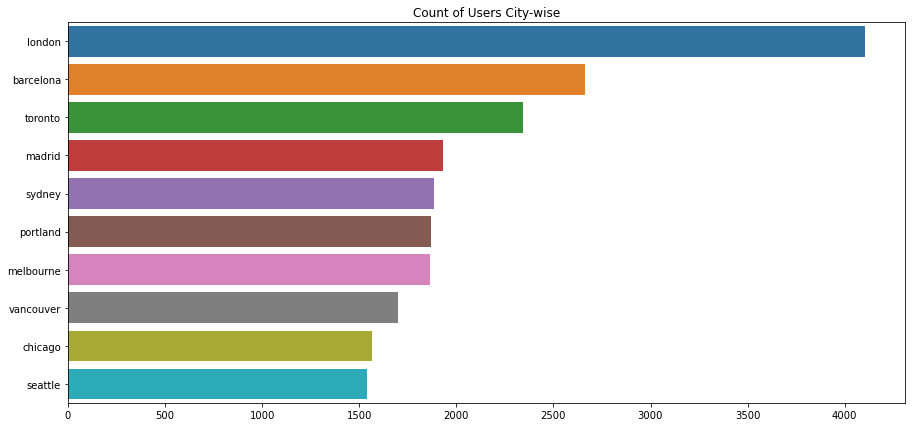

In [26]:
top_cities = users.city.value_counts()[:10]
plt.figure(figsize=(15,7))
sns.barplot(y=top_cities.index,x=top_cities.values)
plt.title('Count of Users City-wise')

outliers detection in age column

Text(0.5, 1.0, 'Outlier detection in Age')

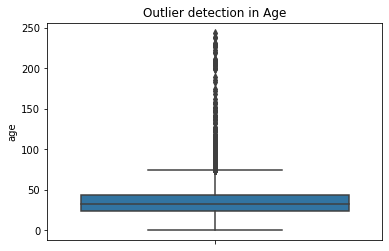

In [27]:
sns.boxplot(y='age', data=users)
plt.title('Outlier detection in Age')

In [28]:
print(sorted(users.age.unique()))

[nan, 0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 36.0, 37.0, 38.0, 39.0, 40.0, 41.0, 42.0, 43.0, 44.0, 45.0, 46.0, 47.0, 48.0, 49.0, 50.0, 51.0, 52.0, 53.0, 54.0, 55.0, 56.0, 57.0, 58.0, 59.0, 60.0, 61.0, 62.0, 63.0, 64.0, 65.0, 66.0, 67.0, 68.0, 69.0, 70.0, 71.0, 72.0, 73.0, 74.0, 75.0, 76.0, 77.0, 78.0, 79.0, 80.0, 81.0, 82.0, 83.0, 84.0, 85.0, 86.0, 87.0, 88.0, 89.0, 90.0, 91.0, 92.0, 93.0, 94.0, 95.0, 96.0, 97.0, 98.0, 99.0, 100.0, 101.0, 102.0, 103.0, 104.0, 105.0, 106.0, 107.0, 108.0, 109.0, 110.0, 111.0, 113.0, 114.0, 115.0, 116.0, 118.0, 119.0, 123.0, 124.0, 127.0, 128.0, 132.0, 133.0, 136.0, 137.0, 138.0, 140.0, 141.0, 143.0, 146.0, 147.0, 148.0, 151.0, 152.0, 156.0, 157.0, 159.0, 162.0, 168.0, 172.0, 175.0, 183.0, 186.0, 189.0, 199.0, 200.0, 201.0, 204.0, 207.0, 208.0, 209.0, 210.0, 212.0, 219.0, 220.0, 223.0, 226.0

We can see there are outliers in age

Treating outliers and converting them to Nan

Text(0.5, 1.0, 'Age Distribution Plot')

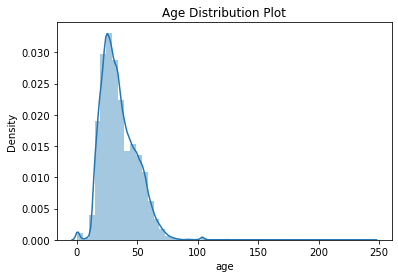

In [29]:
sns.distplot(users.age)
plt.title('Age Distribution Plot')

From the age distribution plot, we can see that there are ages less than 5 and greater than 100 which are practically impossible.
Therefore treating them as outliers

In [30]:
# outlier data became mean
users.loc[(users.age > 100) | (users.age < 5), 'age'] =users.age.mean()

In [31]:
users.isna().sum()

user_id         0
age        110762
city            0
state           1
country      4561
dtype: int64

In [32]:
users['age'].fillna(users.age.mean(),inplace=True)
users.age.isna().sum()

0

In [33]:
users['age'] = users['age'].astype('int64')

In [34]:
users.head(10)

,user_id,age,city,state,country
0,1,34,nyc,new york,usa
1,2,18,stockton,california,usa
2,3,34,moscow,yukon territory,russia
3,4,17,porto,v.n.gaia,portugal
4,5,34,farnborough,hants,united kingdom
5,6,61,santa monica,california,usa
6,7,34,washington,dc,usa
7,8,34,timmins,ontario,canada
8,9,34,germantown,tennessee,usa
9,10,26,albacete,wisconsin,spain


BOOKS DATASET

In [35]:
books.head(2)

,ISBN,title,author,year,publisher
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada


TOP 10 authors based on the number of books they wrote

Text(0.5, 1.0, 'Top 10 Authors')

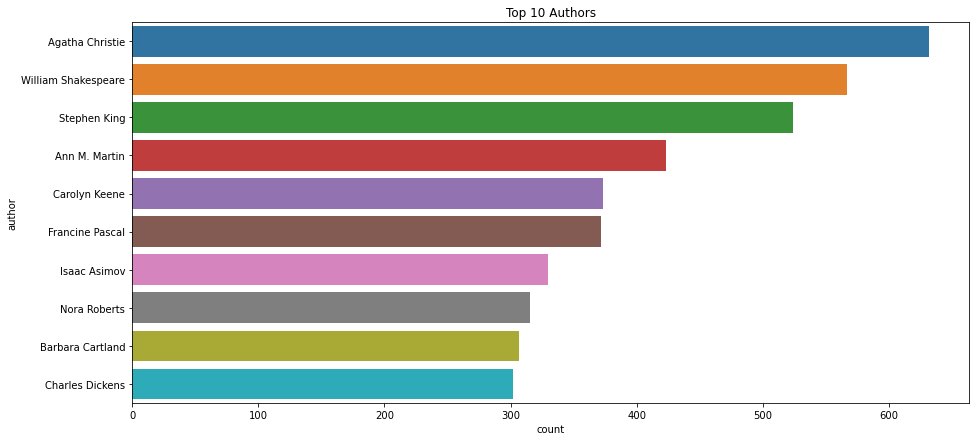

In [36]:
plt.figure(figsize=(15,7))
sns.countplot(y='author',data=books,order=pd.value_counts(books['author']).iloc[:10].index)
plt.title('Top 10 Authors')

Top 10 publishers based on the number of books they published

Text(0.5, 1.0, 'Top 10 Publishers')

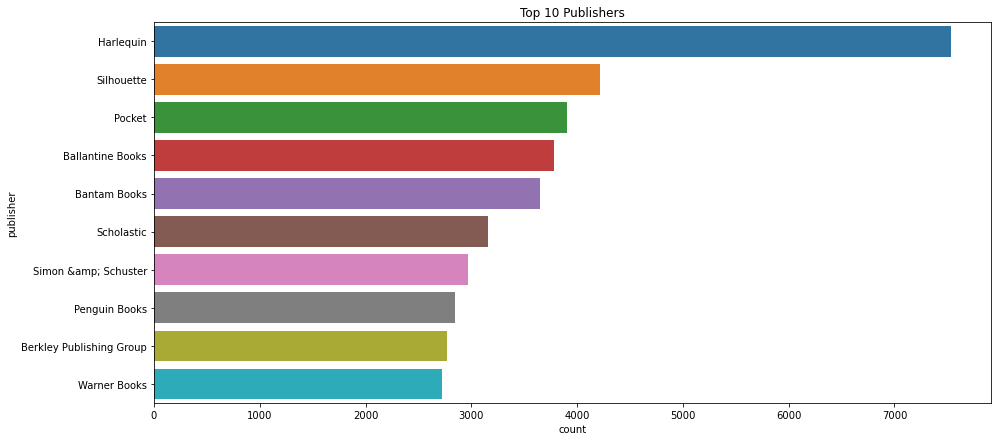

In [37]:
plt.figure(figsize=(15,7))
sns.countplot(y='publisher',data=books,order=pd.value_counts(books['publisher']).iloc[:10].index)
plt.title('Top 10 Publishers')

In [38]:
#unique year of publication
books.year.unique()

array([2002, 2001, 1991, 1999, 2000, 1993, 1996, 1988, 2004, 1998, 1994,
       2003, 1997, 1983, 1979, 1995, 1982, 1985, 1992, 1986, 1978, 1980,
       1952, 1987, 1990, 1981, 1989, 1984, 0, 1968, 1961, 1958, 1974,
       1976, 1971, 1977, 1975, 1965, 1941, 1970, 1962, 1973, 1972, 1960,
       1966, 1920, 1956, 1959, 1953, 1951, 1942, 1963, 1964, 1969, 1954,
       1950, 1967, 2005, 1957, 1940, 1937, 1955, 1946, 1936, 1930, 2011,
       1925, 1948, 1943, 1947, 1945, 1923, 2020, 1939, 1926, 1938, 2030,
       1911, 1904, 1949, 1932, 1928, 1929, 1927, 1931, 1914, 2050, 1934,
       1910, 1933, 1902, 1924, 1921, 1900, 2038, 2026, 1944, 1917, 1901,
       2010, 1908, 1906, 1935, 1806, 2021, '2000', '1995', '1999', '2004',
       '2003', '1990', '1994', '1986', '1989', '2002', '1981', '1993',
       '1983', '1982', '1976', '1991', '1977', '1998', '1992', '1996',
       '0', '1997', '2001', '1974', '1968', '1987', '1984', '1988',
       '1963', '1956', '1970', '1985', '1978', '1973', '1980'

Here we can see that there are two non numbers('DK Publishing Inc','Gallimard') in the year of publication.i.e, there may be wrong data in the year of publication

In [39]:
#investigating the rows having 'DK Publishing Inc' as yearOfPublication
books.loc[books['year'] == 'DK Publishing Inc',:]

,ISBN,title,author,year,publisher
209538,078946697X,"DK Readers: Creating the X-Men, How It All Beg...",2000,DK Publishing Inc,http://images.amazon.com/images/P/078946697X.0...
221678,0789466953,"DK Readers: Creating the X-Men, How Comic Book...",2000,DK Publishing Inc,http://images.amazon.com/images/P/0789466953.0...


From the above dataset it is clear that title, author and year of publication has been changed.

In [40]:
#changing the values of author and year of publication corectly but we dont know the name of the book author so we got the informatio from google
books.loc[books.ISBN == '0789466953','year'] = 2000
books.loc[books.ISBN == '0789466953','author'] = "James Buckley"
books.loc[books.ISBN == '0789466953','publisher'] = "DK Publishing Inc"
books.loc[books.ISBN == '0789466953','title'] = "DK Readers: Creating the X-Men, How Comic Books Come to Life (Level 4: Proficient Readers)"

In [41]:
books.loc[books.ISBN == '078946697X','year'] = 2000
books.loc[books.ISBN == '078946697X','author'] = "Michael Teitelbaum"
books.loc[books.ISBN == '078946697X','publisher'] = "DK Publishing Inc"
books.loc[books.ISBN == '078946697X','title'] = "DK Readers: Creating the X-Men, How It All Began (Level 4: Proficient Readers)"

In [42]:
#investigating the rows having 'Gallimard' as yearOfPublication
books.loc[books['year'] == 'Gallimard',:]

,ISBN,title,author,year,publisher
220731,2070426769,"Peuple du ciel, suivi de 'Les Bergers\"";Jean-M...",2003,Gallimard,http://images.amazon.com/images/P/2070426769.0...


In [43]:
#making required corrections as above, keeping other fields intact
books.loc[books.ISBN == '2070426769','year'] = 2003
books.loc[books.ISBN == '2070426769','author'] = "Jean-Marie Gustave Le ClÃ?Â©zio"
books.loc[books.ISBN == '2070426769','publisher'] = "Gallimard"
books.loc[books.ISBN == '2070426769','title'] = "Peuple du ciel, suivi de 'Les Bergers"

In [44]:
books['year']=pd.to_numeric(books['year'])
books.year.unique()

array([2002, 2001, 1991, 1999, 2000, 1993, 1996, 1988, 2004, 1998, 1994,
       2003, 1997, 1983, 1979, 1995, 1982, 1985, 1992, 1986, 1978, 1980,
       1952, 1987, 1990, 1981, 1989, 1984,    0, 1968, 1961, 1958, 1974,
       1976, 1971, 1977, 1975, 1965, 1941, 1970, 1962, 1973, 1972, 1960,
       1966, 1920, 1956, 1959, 1953, 1951, 1942, 1963, 1964, 1969, 1954,
       1950, 1967, 2005, 1957, 1940, 1937, 1955, 1946, 1936, 1930, 2011,
       1925, 1948, 1943, 1947, 1945, 1923, 2020, 1939, 1926, 1938, 2030,
       1911, 1904, 1949, 1932, 1928, 1929, 1927, 1931, 1914, 2050, 1934,
       1910, 1933, 1902, 1924, 1921, 1900, 2038, 2026, 1944, 1917, 1901,
       2010, 1908, 1906, 1935, 1806, 2021, 2012, 2006, 1909, 2008, 1378,
       1919, 1922, 1897, 2024, 1376, 2037], dtype=int64)

Year  of publication is  in some places and more than 2023 which is invalid. So converting the invalid values from the dataset  to the median values

In [45]:
books.loc[(books['year'] > 2023) | (books['year'] == 0),'year'] = books['year'].median()

#replacing invalid values with median value of Year-Of-Publication


In [46]:
books.isna().sum()

ISBN         0
title        0
author       1
year         0
publisher    2
dtype: int64

We can see here there are two nan values in publisher and author columns so changing them to other

In [47]:
#Filling Nan of Publisher with others
books.publisher.fillna('other',inplace=True)
 #Filling Nan of author with others
books.author.fillna('other',inplace=True)

In [48]:
books.isna().sum()

ISBN         0
title        0
author       0
year         0
publisher    0
dtype: int64

RATINGS DATASET

In [49]:
ratings.head(2)

,user_id,ISBN,rating
0,276725,034545104X,0
1,276726,0155061224,5


In [50]:
Missing_values=ratings.isnull().sum()
Percentage_missing_values=round(ratings.isnull().mean().mul(100),2)

In [51]:
mz_table=pd.concat([Missing_values,Percentage_missing_values],axis=1)
mz_table=mz_table.rename(columns={ratings.index.name:'col_name',0:'Missing_values',1:'Percentage_missing_values'})
mz_table=mz_table.sort_values('Percentage_missing_values',ascending=False)
mz_table

,Missing_values,Percentage_missing_values
user_id,0,0.0
ISBN,0,0.0
rating,0,0.0


In [52]:
ratings.user_id.unique()

array([276725, 276726, 276727, ..., 276709, 276721, 276723], dtype=int64)

In [53]:
ratings.ISBN.nunique()

340556

In [54]:
ratings.rating.unique()

array([ 0,  5,  3,  6,  8,  7, 10,  9,  4,  1,  2], dtype=int64)

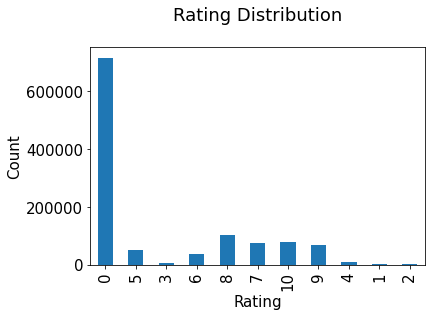

In [55]:
#Distribution of ratings
plt.rc("font", size=15)
ratings['rating'].value_counts(sort=False).plot(kind='bar')
plt.title('Rating Distribution\n')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

Ratings are unevenly distributed also majority values are there in 0. From the given statement the values of ratings should be from 1 to 10.

<AxesSubplot:title={'center':'rating distribution'}, xlabel='rating', ylabel='count'>

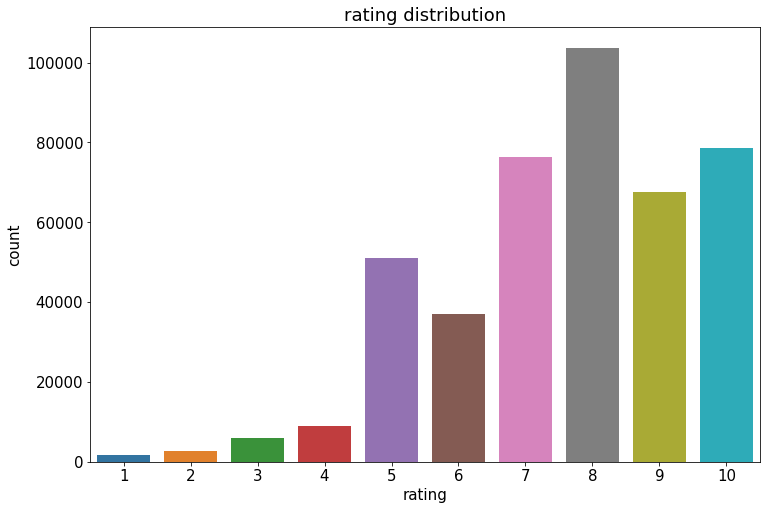

In [56]:
#considering the dataset havig ratings more than 0
ratings_1 = ratings[ratings['rating'] != 0]
plt.figure(figsize=(12, 8))
plt.title('rating distribution')
sns.countplot(data=ratings_1 , x='rating')

8 is the most frequent ratings

In [57]:
#Top 5 books that are rated by most of the users
rating_count = pd.DataFrame(ratings_1.groupby('ISBN')['rating'].count())
rating_count.sort_values('rating', ascending=False).head()

,rating
ISBN,
0316666343,707
0971880107,581
0385504209,487
0312195516,383
0679781587,333


The book with ISBN '0316666343' received the most rating counts. Let’s find out what book it is, and what books are in the top 5.

In [58]:
most_rated_books = pd.DataFrame(['0316666343', '0971880107', '0385504209', '0312195516', '0060928336'], index=np.arange(5), columns = ['ISBN'])
most_rated_books_summary = pd.merge(most_rated_books, books, on='ISBN')
most_rated_books_summary

,ISBN,title,author,year,publisher
0,0316666343,The Lovely Bones: A Novel,Alice Sebold,2002,"Little, Brown"
1,0971880107,Wild Animus,Rich Shapero,2004,Too Far
2,0385504209,The Da Vinci Code,Dan Brown,2003,Doubleday
3,0312195516,The Red Tent (Bestselling Backlist),Anita Diamant,1998,Picador USA
4,0060928336,Divine Secrets of the Ya-Ya Sisterhood: A Novel,Rebecca Wells,1997,Perennial


Here the top 5 books which are having higher rating counts are Novels,so we can say that Novels are the best selling among all other books.

In [59]:
# Create column Rating average 
ratings_1['Avg_Rating']=ratings_1.groupby('ISBN')['rating'].transform('mean')
# Create column Rating sum
ratings_1['Total_No_Of_Users_Rated']=ratings_1.groupby('ISBN')['rating'].transform('count')  

MERGING OF DATASET

In [60]:
Final_Dataset=users.copy()
Final_Dataset=pd.merge(Final_Dataset,ratings_1,on='user_id')
Final_Dataset=pd.merge(Final_Dataset,books,on='ISBN')

In [61]:
Final_Dataset.head(10)

,user_id,age,city,state,country,ISBN,rating,Avg_Rating,Total_No_Of_Users_Rated,title,author,year,publisher
0,8,34,timmins,ontario,canada,0002005018,5,7.666667,9,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada
1,11676,34,n/a,n/a,n/a,0002005018,8,7.666667,9,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada
2,67544,30,toronto,ontario,canada,0002005018,8,7.666667,9,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada
3,116866,34,ottawa,,NaN,0002005018,9,7.666667,9,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada
4,123629,34,kingston,ontario,canada,0002005018,9,7.666667,9,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada
5,200273,34,comber,ontario,canada,0002005018,8,7.666667,9,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada
6,210926,34,guelph,ontario,canada,0002005018,9,7.666667,9,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada
7,219008,60,halifax,nova scotia,canada,0002005018,7,7.666667,9,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada
8,263325,27,fredericton,new brunswick,canada,0002005018,6,7.666667,9,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada
9,8,34,timmins,ontario,canada,074322678X,5,5.000000,1,Where You'll Find Me: And Other Stories,Ann Beattie,2002,Scribner


In [62]:
Final_Dataset.shape

(383842, 13)

Evaluation of final dataset

<AxesSubplot:xlabel='age', ylabel='rating'>

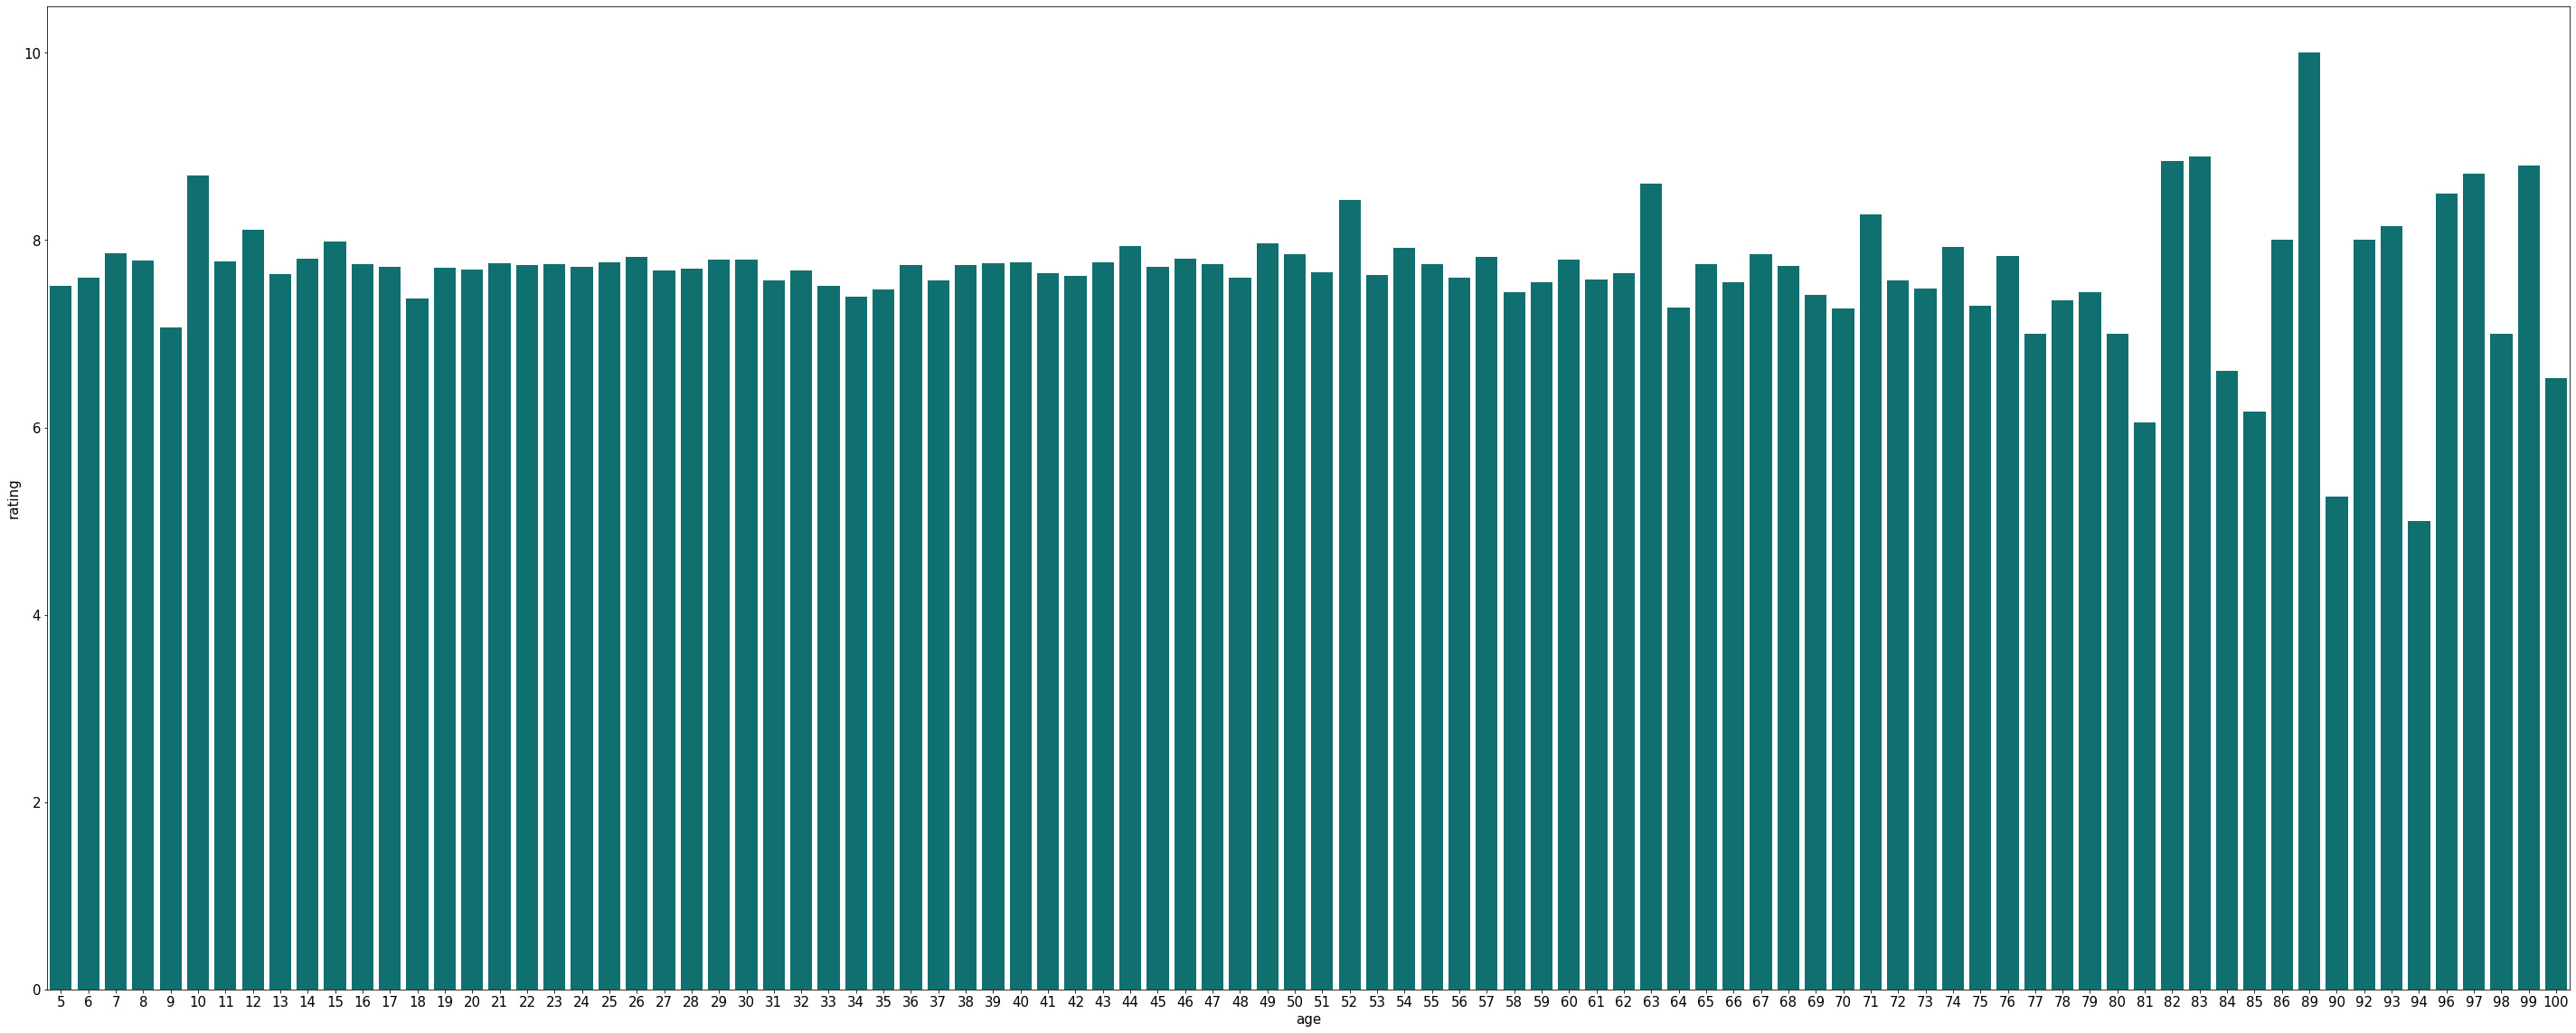

In [63]:
#the age of people who gave most of the ratings
fig= plt.figure(figsize = (50,20))
sns.barplot(x='age', y='rating',data=Final_Dataset, color='teal',errwidth=0)

AGE WISE PREFERENCE OF BOOKS

In [94]:
age_pref=pd.DataFrame(Final_Dataset.groupby(['age'])['title'].value_counts()).rename(columns={'title':'count'}).sort_values(by='count', ascending=False)
age_pref=age_pref.reset_index()
age_pref

,age,title,count
0,34,The Lovely Bones: A Novel,258
1,34,A Painted House,166
2,34,The Red Tent (Bestselling Backlist),166
3,34,The Nanny Diaries: A Novel,157
4,34,The Secret Life of Bees,140
...,...,...,...
280363,33,City Infernal,1
280364,33,City critters: How to live with urban wildlife,1
280365,33,City of Bones,1
280366,33,City of God,1


In [66]:
pd.DataFrame(Final_Dataset.groupby(['age'])['author'].value_counts()).rename(columns={'author':'count'}).sort_values(by='count', ascending=False).reset_index()

,age,author,count
0,34,Stephen King,1296
1,34,John Grisham,936
2,34,Nora Roberts,902
3,34,James Patterson,886
4,34,Mary Higgins Clark,674
...,...,...,...
173000,34,Alex Golson,1
173001,34,Alev Lytle Croutier,1
173002,34,Alessandro Gomarasca,1
173003,34,Alessandra MacInghi Strozzi,1


COUNTRY WISE PREFERENCE OF BOOKS

In [93]:
country_pref=pd.DataFrame(Final_Dataset.groupby(['country'])['title'].value_counts()).rename(columns={'title':'count'}).sort_values(by='count', ascending=False)
country_pref=country_pref.reset_index()
country_pref

,country,title,count
0,usa,The Lovely Bones: A Novel,531
1,usa,The Da Vinci Code,396
2,usa,The Secret Life of Bees,360
3,usa,The Nanny Diaries: A Novel,321
4,usa,A Painted House,309
...,...,...,...
176250,netherlands,Cruel &amp; Unusual (Kay Scarpetta Mysteries (...,1
176251,netherlands,Crossings (Buffy the Vampire Slayer),1
176252,netherlands,Crime and Punishment (Wordsworth Classics),1
176253,netherlands,Cries in the Desert (St. Martin's True Crime L...,1


In [68]:
pd.DataFrame(Final_Dataset.groupby(['country'])['author'].value_counts()).rename(columns={'author':'count'}).sort_values(by='count', ascending=False).reset_index()

,country,author,count
0,usa,Stephen King,3321
1,usa,Nora Roberts,2400
2,usa,James Patterson,1918
3,usa,John Grisham,1838
4,usa,J. K. Rowling,1344
...,...,...,...
96249,netherlands,Marc Levy,1
96250,netherlands,Marc Behm,1
96251,netherlands,Malcom Bradbury,1
96252,netherlands,Malcolm Godden,1


MODEL BUILDING
1.Popularity Based Filtering
    As the name suggests Popularity based recommendation system works with the trend. It basically uses the items which are in trend right now. For example, if any book which is usually bought by every new user then there are chances that it may suggest that book to the user who just signed up.

Weighted Rating(WR)=[vR/(v+m)]+[mC/(v+m)]
where,
v is the number of votes for the book;
m is the minimum votes required to be listed in the chart;
R is the average rating of the book; and
C is the mean vote across the whole report.
Now we find the values of v,m,R,C.

In [69]:
C= Final_Dataset['Avg_Rating'].mean()
m= Final_Dataset['Total_No_Of_Users_Rated'].quantile(0.90)
Top_Books = Final_Dataset.loc[Final_Dataset['Total_No_Of_Users_Rated'] >= m]
print(f'C={C} , m={m}')
Top_Books.shape

C=7.626700569504765 , m=64.0


(38570, 13)

Here we used 90th percentile as our cutoff. In other words, for a book to feature in the charts, it must have more votes than at least 90% of the books in the list.
We see that there are 38570 books which qualify to be in this list. Now, we need to calculate our metric for each qualified book. To do this, we will define a function, weighted_rating() and define a new feature score, of which we’ll calculate the value by applying this function to our DataFrame of qualified books:

In [70]:
def weighted_rating(x, m=m, C=C):
    v = x['Total_No_Of_Users_Rated']
    R = x['Avg_Rating']
    return (v/(v+m) * R) + (m/(m+v) * C)
Top_Books['Score'] = Top_Books.apply(weighted_rating,axis=1)
#Sorting books based on score calculated above
Top_Books = Top_Books.sort_values('Score', ascending=False)

In [71]:
#Keeping only one entry of each book
Top_Books=Top_Books.sort_values('Score', ascending=False).drop_duplicates('ISBN').sort_index()
cm=sns.light_palette('yellow',as_cmap=True)
#Sorting books based on score calculated above
Top_Books = Top_Books.sort_values('Score', ascending=False)

In [72]:
#Printing the top 20 books
Top_Books[['title', 'Total_No_Of_Users_Rated', 'rating', 'Score']].reset_index(drop=True).head(20).style.background_gradient(cmap=cm)

,title,Total_No_Of_Users_Rated,rating,Score
0,Harry Potter and the Goblet of Fire (Book 4),137,10,8.741835
1,Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback)),313,10,8.716469
2,Harry Potter and the Order of the Phoenix (Book 5),206,8,8.700403
3,To Kill a Mockingbird,214,9,8.640679
4,Harry Potter and the Prisoner of Azkaban (Book 3),133,9,8.609690
5,"The Return of the King (The Lord of the Rings, Part 3)",77,10,8.596517
6,Harry Potter and the Prisoner of Azkaban (Book 3),141,9,8.595653
7,Harry Potter and the Sorcerer's Stone (Book 1),119,10,8.508791
8,Harry Potter and the Chamber of Secrets (Book 2),189,10,8.490549
9,Harry Potter and the Chamber of Secrets (Book 2),126,6,8.484783


The Popularity based recommender provide a general chart of recommended books to all the users. They are not sensitive to the interests and tastes of a particular user.

2.Collaborative Filtering method
    There are two categories of collaborative filtering algorithms: memory based and model based.

Model Based Collaborative Filtering Recommender
The goal of the recommender system is to predict user preference for a set of items based on the past experience. Two the most popular approaches are Content-Based and Collaborative Filtering.
Collaborative filtering is a technique used by websites like Amazon, YouTube, and Netflix. It filters out items that a user might like on the basis of reactions of similar users. 

In [73]:
#Model based approach involves building machine learning algorithms to predict user's ratings. 
#They involve dimensionality reduction methods that reduce high dimensional matrix containing abundant number of missing values with a much smaller matrix in lower-dimensional space.
#The goal of this section is to compare SVD and NMF algorithms, try different configurations of parameters and explore obtained results.
import scipy
import math
import sklearn
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse.linalg import svds

In [74]:
#This analysis will focus on book recommendations based on Book-Crossing dataset.
#To reduce the dimensionality of the dataset and avoid running into memory error we will focus on users with at least 3 ratings and top 10% most frequently rated books.
ratings_1.rename(columns = {'User-ID':'user_id' ,'ISBN':'isbn' ,'Book-Rating':'book_rating'},inplace=True)
user_ratings_threshold = 3
filter_users = ratings_1['user_id'].value_counts()
filter_users_list = filter_users[filter_users >= user_ratings_threshold].index.to_list()
df_ratings_top = ratings_1[ratings_1['user_id'].isin(filter_users_list)]
print('Filter: users with at least %d ratings\nNumber of records: %d' % (user_ratings_threshold, len(df_ratings_top)))

Filter: users with at least 3 ratings
Number of records: 368579


In [75]:
book_ratings_threshold_perc = 0.1
book_ratings_threshold = len(df_ratings_top['isbn'].unique()) * book_ratings_threshold_perc
filter_books_list = df_ratings_top['isbn'].value_counts().head(int(book_ratings_threshold)).index.to_list()
df_ratings_top = df_ratings_top[df_ratings_top['isbn'].isin(filter_books_list)]
print('Filter: top %d%% most frequently rated books\nNumber of records: %d' % (book_ratings_threshold_perc*100, len(df_ratings_top)))

Filter: top 10% most frequently rated books
Number of records: 176599


SVD and NMF models comparison
Singular Value Decomposition (SVD) and Non-negative Matrix Factorization (NMF) are matrix factorization techniques used for dimensionality reduction. Surprise package provides implementation of those algorithms.

In [76]:
!pip install scikit-surprise

In [95]:
from surprise import Dataset, Reader
from surprise import SVD, NMF
from surprise.model_selection import cross_validate, train_test_split, GridSearchCV
df=df_ratings_top.copy()
reader = Reader(rating_scale=(1, 10))
data = Dataset.load_from_df(df[['user_id', 'isbn', 'rating']], reader)
data

In [78]:
model_svd = SVD()
cv_results_svd = cross_validate(model_svd, data, cv=3)
pd.DataFrame(cv_results_svd).mean()

test_rmse    1.602978
test_mae     1.239958
fit_time     1.999426
test_time    0.470830
dtype: float64

In [79]:
model_nmf = NMF()
cv_results_nmf = cross_validate(model_nmf, data, cv=3)
pd.DataFrame(cv_results_nmf).mean()

test_rmse    2.631239
test_mae     2.245239
fit_time     4.808911
test_time    0.417143
dtype: float64

It's clear that for the given dataset much better results can be obtained with SVD approach - both in terms of accuracy and training / testing time.

Optimisation of SVD algorithm
Grid Search Cross Validation computes accuracy metrics for an algorithm on various combinations of parameters, over a cross-validation procedure. It's useful for finding the best configuration of parameters.


It is used to find the best setting of parameters:
n_factors - the number of factors
n_epochs - the number of iteration of the SGD procedure
lr_all - the learning rate for all parameters
reg_all - the regularization term for all parameters
As a result, regarding the majority of parameters, the default setting is the most optimal one. The improvement obtained with Grid Search is very small.


In [80]:
param_grid = {'n_factors': [80,100],
              'n_epochs': [5, 20],
              'lr_all': [0.002, 0.005],
              'reg_all': [0.2, 0.4]}

gs = GridSearchCV(SVD, param_grid, measures=['rmse', 'mae'], cv=3)
gs.fit(data)

print(gs.best_score['rmse'])
print(gs.best_params['rmse'])

1.596037300100526
{'n_factors': 80, 'n_epochs': 20, 'lr_all': 0.005, 'reg_all': 0.2}


Analysis of Collaborative Filtering model results
In this part, let's examine in detail the results obtained by the SVD model that provided the best RMSE score.

In [81]:
trainset, testset = train_test_split(data, test_size=0.2)

model = SVD(n_factors=80, n_epochs=20, lr_all=0.005, reg_all=0.2)
model.fit(trainset)
predictions = model.test(testset)
     

In [82]:
df_pred = pd.DataFrame(predictions, columns=['user_id', 'isbn', 'actual_rating', 'pred_rating', 'details'])
df_pred['impossible'] = df_pred['details'].apply(lambda x: x['was_impossible'])
df_pred['pred_rating_round'] = df_pred['pred_rating'].round()
df_pred['abs_err'] = abs(df_pred['pred_rating'] - df_pred['actual_rating'])
df_pred.drop(['details'], axis=1, inplace=True)
df_pred.sample(5)

,user_id,isbn,actual_rating,pred_rating,impossible,pred_rating_round,abs_err
30325,259258,0064400034,7.0,7.700175,False,8.0,0.700175
27805,95903,044922788X,8.0,8.001012,False,8.0,0.001012
15030,36121,0590981811,9.0,8.032419,False,8.0,0.967581
7786,164675,0440221463,6.0,7.479906,False,7.0,1.479906
23261,31412,0345438329,7.0,8.001858,False,8.0,1.001858


Distribution of actual and predicted ratings in the test set According to the distribution of actual ratings of books in the test set, the biggest part of users give positive scores - between 7 and 10. The mode equals 8 but count of ratings 7, 9, 10 is also noticeable. The distribution of predicted ratings in the test set is visibly different. One more time, 8 is a mode but scores 7, 9 and 10 are clearly less frequent.

It shows that the recommender system is not perfect and it cannot reflect the real distribution of book ratings.

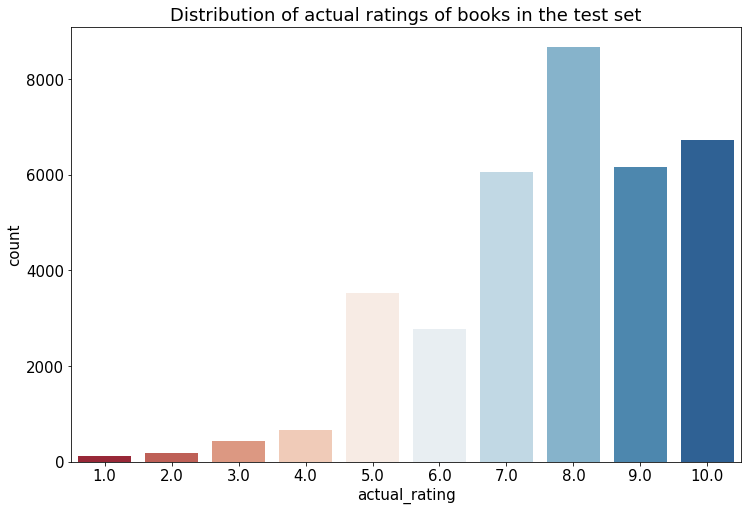

In [83]:
palette = sns.color_palette("RdBu", 10)
plt.figure(figsize=(12, 8))
sns.countplot(x='actual_rating', data=df_pred, palette=palette)
plt.title('Distribution of actual ratings of books in the test set')
plt.show()

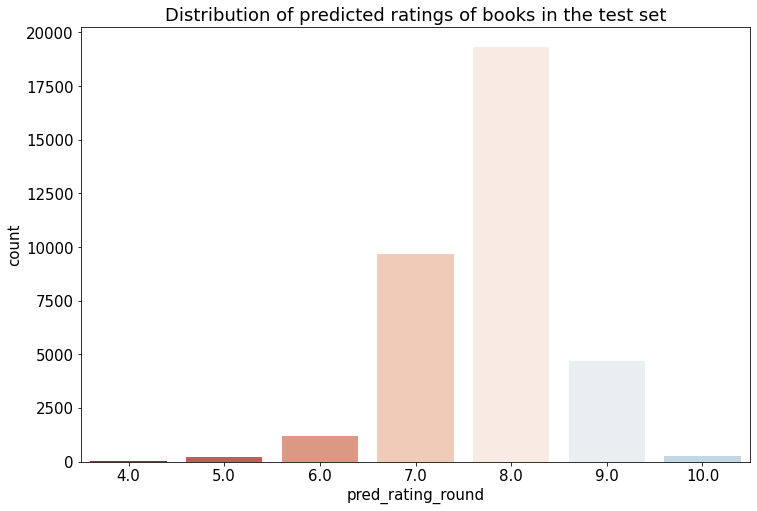

In [84]:
palette = sns.color_palette("RdBu", 10)
plt.figure(figsize=(12, 8))
sns.countplot(x='pred_rating_round', data=df_pred, palette=palette)
plt.title('Distribution of predicted ratings of books in the test set')
plt.show()

Absolute error of predicted ratings
The distribution of absolute errors is right-skewed, showing that the majority of errors is small: between 0 and 1. There is a long tail that indicates that there are several observations for which the absolute error was close to 10.

How good/bad the model is with predicting certain scores? As expected from the above charts, the model deals very well with predicting score = 8 (the most frequent value). The further the rating from score = 8, the higher the absolute error. The biggest errors happen to observations with scores 1 or 2 which indicates that probably the model is predicting high ratings for those observations.

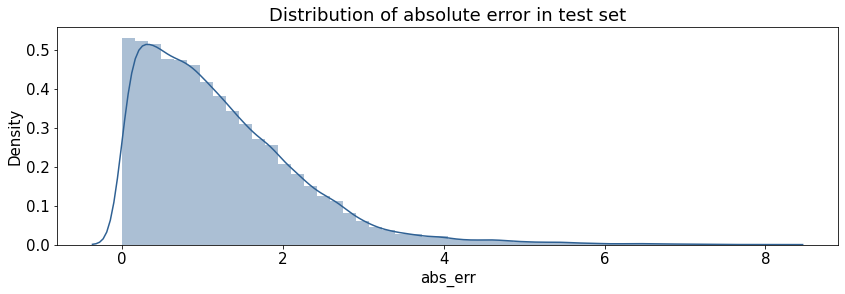

In [85]:
df_pred_err = df_pred.groupby('actual_rating')['abs_err'].mean().reset_index()
plt.figure(figsize=(14, 4))
sns.distplot(df_pred['abs_err'], color='#2f6194')
plt.title('Distribution of absolute error in test set')
plt.show()
     

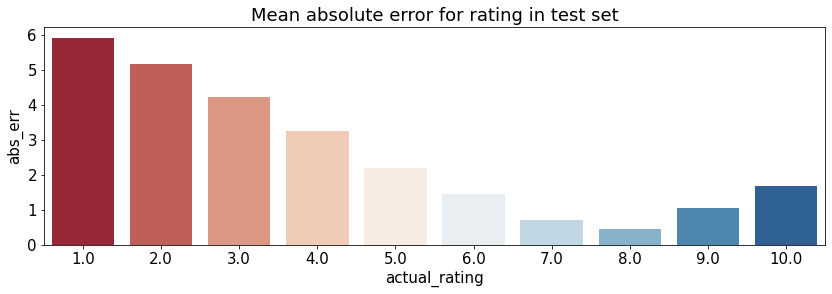

In [86]:
df_pred_err = df_pred.groupby('actual_rating')['abs_err'].mean().reset_index()
plt.figure(figsize=(14, 4))
sns.barplot(x='actual_rating', y='abs_err', data=df_pred_err, palette=palette)
plt.title('Mean absolute error for rating in test set')
plt.show()

Analysis of predicted ratings of a particular user
For this part of the analysis, the user with id 193458 was selected. By analyzing book ratings by this user, it can be noted that he/she likes diverse types of readings: English romantic novels (Pride and Prejudice, Sense and Sensibility), fantasy (Narnia) as well as historical novels (Schindler's List). Among the recommended books there are other works from Narnia's series, two historical novels and one romance which correlates with user's previous preferences.

In [87]:
df_books = books.copy()
df_books.rename(columns = {'ISBN':'isbn'},inplace=True)
df_ext = df.merge(df_books[['isbn', 'title']], on='isbn', how='left')
df_ext = df_ext.merge(df_pred[['isbn', 'user_id', 'pred_rating']], on=['isbn', 'user_id'], how='left')
df_ext

,user_id,isbn,rating,Avg_Rating,Total_No_Of_Users_Rated,title,pred_rating
0,276747,0060517794,9,8.000000,30,Little Altars Everywhere,NaN
1,276747,0671537458,9,7.176471,17,Waiting to Exhale,NaN
2,276747,0679776818,8,7.476190,21,Birdsong: A Novel of Love and War,7.756781
3,276762,0380711524,5,7.625000,16,See Jane Run,7.827445
4,276772,0553572369,7,6.625000,8,Pay Dirt (Mrs. Murphy Mysteries (Paperback)),NaN
...,...,...,...,...,...,...,...
176594,276688,0836236688,10,8.333333,15,Dilbert: Seven Years Of Highly Defective Peopl...,NaN
176595,276688,0892966548,10,8.000000,4,Killer Market: A Deborah Knott Mystery (Debora...,NaN
176596,276688,1551669315,6,7.200000,5,The Third Wife,7.943292
176597,276704,0345386108,6,6.852941,34,Winter Moon,NaN


In [88]:
#Train set: Top rated books

selected_user_id = 193458
df_user = df_ext[df_ext['user_id']==selected_user_id]

df_user[(df_user['pred_rating'].isna())&(df_user['rating']>=9)].sample(10)
     

,user_id,isbn,rating,Avg_Rating,Total_No_Of_Users_Rated,title,pred_rating
124937,193458,0345361792,10,8.607735,181,A Prayer for Owen Meany,NaN
124966,193458,0789404257,9,9.000000,4,Eyewitness Travel Guide to Italy (revised),NaN
124936,193458,0345342569,9,7.947368,19,Shoeless Joe,NaN
124935,193458,0330352695,9,7.615385,13,Four Letters of Love,NaN
124962,193458,0671880314,9,8.305556,36,Schindler's List,NaN
124975,193458,1853260169,10,8.153846,13,Sense and Sensibility (Wordsworth Classics),NaN
124973,193458,1853260002,10,8.217391,23,Pride &amp; Prejudice (Wordsworth Classics),NaN
124918,193458,0064471063,9,8.518519,27,The Horse and His Boy,NaN
124916,193458,0064471047,9,8.714286,42,"The Lion, the Witch, and the Wardrobe (The Chr...",NaN
124926,193458,0140620125,9,8.133333,15,Wuthering Heights (Penguin Popular Classics),NaN


In [89]:
#Test set: predicted top rated books

df_user[df_user['pred_rating'].notna()].sort_values('pred_rating', ascending=False).head(5)

,user_id,isbn,rating,Avg_Rating,Total_No_Of_Users_Rated,title,pred_rating
124930,193458,0142001740,9,8.452769,307,The Secret Life of Bees,8.386605
124917,193458,0064471055,9,8.545455,22,Prince Caspian (rack) : The Return to Narnia (...,8.252525
124921,193458,0064471098,9,8.733333,15,The Silver Chair,8.203818
124941,193458,0345424719,8,8.017544,57,A Widow for One Year,7.839565
124963,193458,0679429220,9,7.794393,107,Midnight in the Garden of Good and Evil: A Sav...,7.834092


In [90]:
#Test set: actual top rated books

df_user[df_user['pred_rating'].notna()].sort_values('rating', ascending=False).head(5)

,user_id,isbn,rating,Avg_Rating,Total_No_Of_Users_Rated,title,pred_rating
124917,193458,0064471055,9,8.545455,22,Prince Caspian (rack) : The Return to Narnia (...,8.252525
124921,193458,0064471098,9,8.733333,15,The Silver Chair,8.203818
124930,193458,0142001740,9,8.452769,307,The Secret Life of Bees,8.386605
124963,193458,0679429220,9,7.794393,107,Midnight in the Garden of Good and Evil: A Sav...,7.834092
124941,193458,0345424719,8,8.017544,57,A Widow for One Year,7.839565
